
# The absorbing-bound extension: capacity-limited accumulation with a decision

IB_memo_v6 solves the bead task — a *volatile* source with a stabilizing,
**non-absorbing** bound (§6-7 of the memo: a leaky accumulator, discretized
under a capacity constraint into a bounded ladder that holds a category
forever). That is the right model for ongoing tracking/filtering, but it is
not the model the lab's DDM work uses. Standard 2AFC accumulate-to-bound
tasks are **stationary** (no hazard, no leak) and **absorbing**: the
accumulator runs until it hits a decision bound, and hitting the bound *is*
the response.

This notebook builds the missing piece: the same "how does capacity limit
the accumulator" question, asked in the absorbing-bound (DDM) setting
instead of the non-absorbing (bead task) setting. It does not touch
`ib_core.py` — everything here lives in `utilities/absorbing_ib.py`, a new,
self-contained module.

**The bridge is a classical, exact one**, not a new assumption: a
discrete-time, discrete-state random walk with absorbing barriers converges
to the drift-diffusion model as the number of interior states grows and step
size shrinks to match (Feller 1968; this is in fact Ratcliff's 1978 original
derivation of the diffusion model, as the continuum limit of a random-walk
model). That convergence parameter — how many discrete, distinguishable
states of accumulated evidence the walk is allowed between the bounds — is
exactly a *capacity* in the memo's sense. Fixing the physical decision bound
`a`, drift `v`, and noise `s` (i.e. fixing the task and the observer's
sensitivity to it) and asking what happens as the number of interior states
`k` shrinks is the absorbing-bound analogue of the memo's central question.

**What this notebook does:**
1. Builds the discrete absorbing chain and solves it exactly (fundamental-matrix algebra, no simulation needed for the answer — simulation is used only to validate).
2. Shows how it's parameterized to match a target continuous DDM (`v`, `s`, `a`), and derives a capacity floor `k_min` — the absorbing-bound analogue of the memo's `beta_c`.
3. Sweeps capacity `k` and shows convergence of accuracy and mean RT onto the continuous DDM's analytic values as `k -> infinity`.
4. Shows the RT-distribution-shape signature of low capacity: visible discreteness/banding, not just a shift in mean.
5. Flags what's still missing — this notebook uses a fixed, uniformly-spaced ladder by construction, not yet the *information-optimal* (IB) placement the memo derives for the non-absorbing case.


In [1]:

import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "utilities"))

import numpy as np
import matplotlib.pyplot as plt
from absorbing_ib import (
    walk_params_from_ddm, k_min_for_validity,
    build_absorbing_chain, exact_absorption_stats, exact_rt_distribution,
    simulate_discrete_chain, simulate_ddm,
    ddm_analytic_accuracy, ddm_analytic_mean_rt, capacity_frontier,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False



## 1. The discrete chain

States `0, 1, ..., k` on the belief axis. States `0` and `k` are absorbing —
reaching one *is* the choice. States `1, ..., k-1` are transient: an
evidence token moves the state up one rung with probability `p`, down one
rung with probability `1-p` (an ordered chain with uniform step size, the
absorbing-bound counterpart of the memo's non-absorbing "bounded ladder,"
§6, Figure 5c).

For a small, concrete example: `k = 4` (three transient states, `1, 2, 3`),
with an up-probability `p = 0.65` (evidence favors the upper/correct bound).


In [2]:

k_demo, p_demo = 4, 0.65
Q, R, transient_states = build_absorbing_chain(k_demo, p_demo)

print("transient states:", transient_states)
print("\nQ (transient -> transient):\n", np.round(Q, 3))
print("\nR (transient -> [absorb-lower, absorb-upper]):\n", np.round(R, 3))


transient states: [1 2 3]

Q (transient -> transient):
 [[0.   0.65 0.  ]
 [0.35 0.   0.65]
 [0.   0.35 0.  ]]

R (transient -> [absorb-lower, absorb-upper]):
 [[0.35 0.  ]
 [0.   0.  ]
 [0.   0.65]]



### Exact solution via the fundamental matrix

For an absorbing Markov chain with transient block `Q` and
transient-to-absorbing block `R`, the fundamental matrix
`N = (I - Q)^-1` gives, in one linear solve and with no simulation:

- `N @ 1` — expected number of steps to absorption from each transient state
- `N @ R` — the probability of ending at each absorbing state from each transient state

This is exact linear algebra, in the same spirit as the memo's exact
Blahut-Arimoto / HMM-recursion computations (never Monte Carlo where an
exact answer is available). Simulation below is used only to *validate* it.


In [3]:

z0_index = 1  # start at transient state '2' (the middle rung, 0-based index into [1,2,3])
stats = exact_absorption_stats(Q, R, z0_index)
print(f"starting at state {transient_states[z0_index]} of 0..{k_demo}")
print(f"  P(absorb lower)  = {stats['p_lower']:.4f}")
print(f"  P(absorb upper)  = {stats['p_upper']:.4f}")
print(f"  E[steps to absorb] = {stats['expected_steps']:.4f}")

# validate against direct simulation of the same discrete chain
steps_sim, choice_sim = simulate_discrete_chain(k_demo, p_demo, z0_index,
                                                 n_trials=200_000, n_max=500, seed=0)
print(f"\nsimulated: P(upper) = {np.nanmean(choice_sim):.4f}, "
      f"E[steps] = {np.nanmean(steps_sim):.4f}  (200,000 trials)")


starting at state 2 of 0..4
  P(absorb lower)  = 0.2248
  P(absorb upper)  = 0.7752
  E[steps to absorb] = 3.6697

simulated: P(upper) = 0.7726, E[steps] = 3.6630  (200,000 trials)



## 2. Matching the chain to a continuous DDM, and a capacity floor

`walk_params_from_ddm(v, s, a, k)` implements the classical random-walk ->
diffusion correspondence: fix the bound separation `a`, drift `v`, and noise
`s` (i.e. fix the task and the observer's sensitivity to it, exactly as a
standard DDM fit would), pick a capacity `k` (number of interior rungs), and
the step size `eps = a/k` and step duration `tau` and up-probability `p` are
then *determined* — not free parameters. Larger `k` means smaller, faster,
individually-less-informative steps; smaller `k` means fewer, larger, more
informative-looking single steps.

That "more informative per step" property is exactly why very small `k`
breaks the correspondence: `p = 0.5*(1 + v*a / (k*s^2))` must stay in
`(0, 1)`, which requires

    k > k_min = |v| * a / s^2

Below `k_min` a single step would need to carry more evidence than the
entire bound separation allows for the diffusion match to remain a valid
probability. This is the absorbing-bound analogue of the memo's `beta_c`
(§2.3): a hard floor on how coarse the representation can be before the
construction itself stops making sense, not just a floor on how well it
performs.


In [4]:

v, s, a = 0.6, 1.0, 2.0   # example DDM: moderate drift, unit noise, bound separation 2
kmin = k_min_for_validity(v, s, a)
print(f"DDM params: v={v}, s={s}, a={a}  ->  k_min = {kmin:.3f}")

print(f"\n{'k':>5} {'p':>8} {'tau':>10} {'eps':>8}")
for k in [2, 3, 5, 10, 30, 100]:
    wp = walk_params_from_ddm(v, s, a, k)
    flag = "" if 0 < wp['p'] < 1 else "  <- invalid (k <= k_min)"
    print(f"{k:5d} {wp['p']:8.4f} {wp['tau']:10.5f} {wp['eps']:8.4f}{flag}")


DDM params: v=0.6, s=1.0, a=2.0  ->  k_min = 1.200

    k        p        tau      eps
    2   0.8000    1.00000   1.0000
    3   0.7000    0.44444   0.6667
    5   0.6200    0.16000   0.4000
   10   0.5600    0.04000   0.2000
   30   0.5200    0.00444   0.0667
  100   0.5060    0.00040   0.0200



## 3. Convergence to the continuous DDM as capacity grows

Sweep `k` (holding `v`, `s`, `a` fixed — i.e. holding the task and the
observer's raw sensitivity fixed, varying only representational capacity)
and compute the *exact* accuracy and mean RT at each `k`. These should
converge onto the continuous DDM's closed-form values (computed
independently via the hitting-time ODE, and cross-checked against direct
Euler-Maruyama simulation of the continuous process) as `k -> infinity`.


In [5]:

z_frac = 0.5  # unbiased start
k_list = np.unique(np.round(np.geomspace(2, 800, 60)).astype(int))
frontier = capacity_frontier(k_list, v, s, a, z_frac=z_frac)

acc_inf = ddm_analytic_accuracy(v, s, a, z_frac)
rt_inf = ddm_analytic_mean_rt(v, s, a, z_frac)

rt_sim, ch_sim = simulate_ddm(v, s, a, z_frac, dt=1e-3, n_trials=40_000, t_max=30, seed=0)
print(f"continuous DDM, analytic:   accuracy = {acc_inf:.4f}, mean RT = {rt_inf:.4f}")
print(f"continuous DDM, simulated:  accuracy = {np.nanmean(ch_sim):.4f}, "
      f"mean RT = {np.nanmean(rt_sim):.4f}  (40,000 trials, dt=1e-3)")


continuous DDM, analytic:   accuracy = 0.7685, mean RT = 0.8951
continuous DDM, simulated:  accuracy = 0.7740, mean RT = 0.9292  (40,000 trials, dt=1e-3)


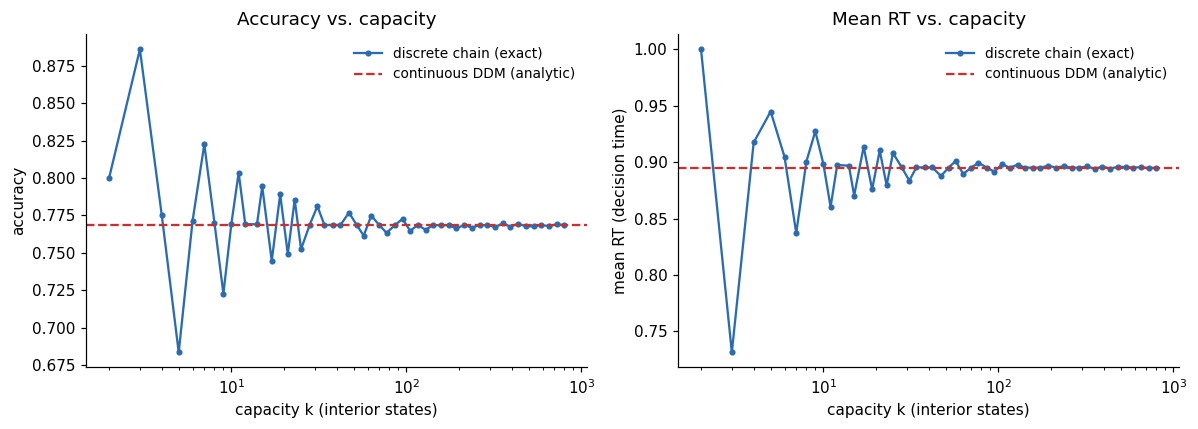

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(frontier['k'], frontier['accuracy'], 'o-', ms=3, color='#2b6cb0', label='discrete chain (exact)')
ax.axhline(acc_inf, color='#c53030', ls='--', label='continuous DDM (analytic)')
ax.set_xscale('log')
ax.set_xlabel('capacity k (interior states)')
ax.set_ylabel('accuracy')
ax.set_title('Accuracy vs. capacity')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.plot(frontier['k'], frontier['mean_rt'], 'o-', ms=3, color='#2b6cb0', label='discrete chain (exact)')
ax.axhline(rt_inf, color='#c53030', ls='--', label='continuous DDM (analytic)')
ax.set_xscale('log')
ax.set_xlabel('capacity k (interior states)')
ax.set_ylabel('mean RT (decision time)')
ax.set_title('Mean RT vs. capacity')
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()



Both curves converge cleanly onto the continuous DDM's values as `k` grows,
which validates the construction — this is the expected, known limit, and
recovering it exactly is the sanity check, not the finding.

The finding is in the *approach*: it is not a smooth, monotonic shrinkage
toward the continuous values. At small `k` there is visible non-monotonic
structure — particular `k` values do noticeably better or worse than their
neighbors, because how the bound separation divides into `k` rungs
determines whether the (fixed) start point lands near the middle of a rung
or near a boundary between rungs, a discreteness/parity effect with no
analogue in the continuous model. This is the same qualitative lesson as the
memo's own staircase frontier (Figure 2a) and uneven branch structure
(§2.2): capacity-limited performance is not a smooth rescaling of the
unconstrained solution, and shouldn't be modeled as one.



## 4. RT-distribution shape: the behavioral signature of low capacity

A capacity cut changes more than mean RT and accuracy — it changes the
*shape* of the RT distribution. With few rungs, only a few distinct step
counts are possible before absorption, so the RT distribution should show
visible banding/discreteness at low `k`, smoothing into the familiar
right-skewed continuous shape as `k` grows. This is a candidate behavioral
signature in the same spirit as the memo's confidence-report prediction
(§2.4): something a standard-DDM fit doesn't have a reason to produce, that
a capacity account does.

`exact_rt_distribution` gets the full distribution over step counts exactly
(no simulation) via the same fundamental-matrix machinery, propagated one
step at a time.


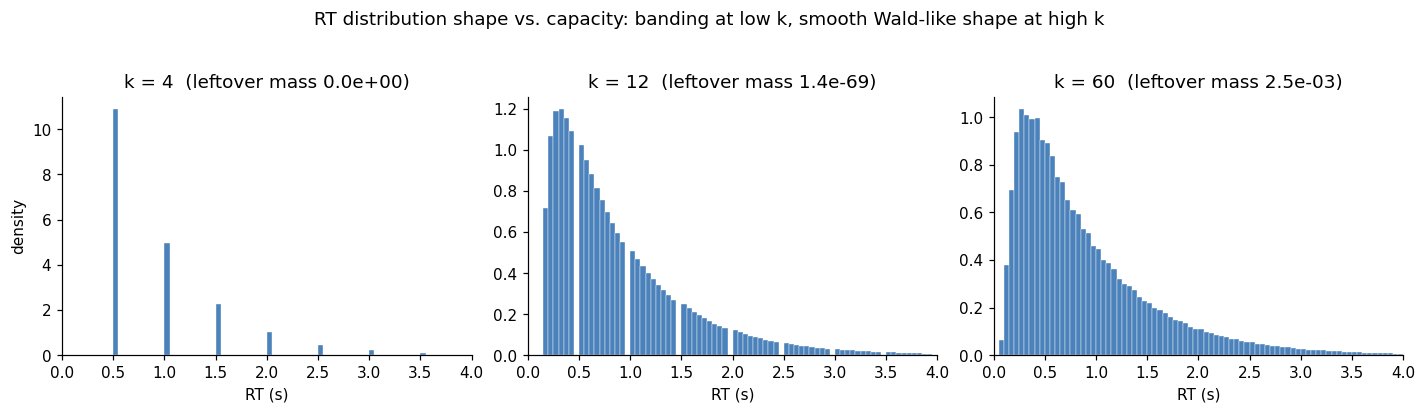

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=False)

for ax, k in zip(axes, [4, 12, 60]):
    wp = walk_params_from_ddm(v, s, a, k)
    z0 = int(np.clip(round(z_frac * k), 1, k - 1)) - 1
    Qk, Rk, _ = build_absorbing_chain(k, wp['p'])
    n_max = 4000
    hits, leftover = exact_rt_distribution(Qk, Rk, z0, n_max=n_max)
    rt_axis = np.arange(1, n_max + 1) * wp['tau']
    total = hits.sum(1)  # P(absorbed at step n), either boundary

    # bin into a fixed real-time grid so different k are comparable
    bins = np.linspace(0, 4, 81)
    dig = np.digitize(rt_axis, bins) - 1
    density = np.zeros(len(bins) - 1)
    for b, m in zip(dig, total):
        if 0 <= b < len(density):
            density[b] += m
    density /= (bins[1] - bins[0])

    ax.bar(bins[:-1], density, width=bins[1] - bins[0], align='edge',
           color='#2b6cb0', alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.set_title(f'k = {k}  (leftover mass {leftover:.1e})')
    ax.set_xlabel('RT (s)')
    ax.set_xlim(0, 4)

axes[0].set_ylabel('density')
fig.suptitle('RT distribution shape vs. capacity: banding at low k, smooth Wald-like shape at high k', y=1.03)
fig.tight_layout()
plt.show()



## 5. Validation summary

Two independent checks, collected here:

1. **Exact discrete-chain solution vs. simulation of that same discrete chain** — confirms the fundamental-matrix algebra is implemented correctly.
2. **Discrete chain at large k vs. direct Euler-Maruyama simulation of the continuous DDM** — confirms the random-walk/diffusion correspondence is being used correctly, independent of the analytic hitting-time formulas.


In [8]:

# 1. exact vs. simulated discrete chain, at a middling k
k_val, p_val = 15, walk_params_from_ddm(v, s, a, 15)['p']
z0 = int(np.clip(round(z_frac * k_val), 1, k_val - 1)) - 1
Qc, Rc, _ = build_absorbing_chain(k_val, p_val)
exact = exact_absorption_stats(Qc, Rc, z0)
steps_sim, ch_sim = simulate_discrete_chain(k_val, p_val, z0, n_trials=300_000, n_max=2000, seed=3)
print("discrete chain, k =", k_val)
print(f"  accuracy   exact={exact['p_upper']:.4f}   simulated={np.nanmean(ch_sim):.4f}")
print(f"  E[steps]   exact={exact['expected_steps']:.4f}   simulated={np.nanmean(steps_sim):.4f}")

# 2. large-k discrete chain vs. simulated continuous DDM
k_big = 400
wp_big = walk_params_from_ddm(v, s, a, k_big)
z0b = int(np.clip(round(z_frac * k_big), 1, k_big - 1)) - 1
Qb, Rb, _ = build_absorbing_chain(k_big, wp_big['p'])
exact_big = exact_absorption_stats(Qb, Rb, z0b)
rt_cont, ch_cont = simulate_ddm(v, s, a, z_frac, dt=1e-3, n_trials=40_000, t_max=30, seed=4)
print(f"\ndiscrete chain, k = {k_big} (exact):        "
      f"accuracy = {exact_big['p_upper']:.4f}, mean RT = {exact_big['expected_steps']*wp_big['tau']:.4f}")
print(f"continuous DDM (simulated, 40,000 trials):  "
      f"accuracy = {np.nanmean(ch_cont):.4f}, mean RT = {np.nanmean(rt_cont):.4f}")


discrete chain, k = 15
  accuracy   exact=0.7944   simulated=0.7938
  E[steps]   exact=48.9543   simulated=48.9049



discrete chain, k = 400 (exact):        accuracy = 0.7685, mean RT = 0.8951
continuous DDM (simulated, 40,000 trials):  accuracy = 0.7713, mean RT = 0.9312



## 6. Where this leaves us

**What's established here, exactly and validated:**
- The bead task's non-absorbing bounded ladder and the DDM's absorbing accumulate-to-bound process are two instances of the same underlying question (capacity-limited discrete accumulation), differing only in the boundary condition.
- A capacity `k` (or `log2 k` bits, as an upper-bound proxy — the memo's own alphabet-ceiling caveat, §2.2/Figure 3d, applies here too since edge states are visited unevenly) has a well-defined, exact effect on accuracy and RT in the absorbing case, converging to the standard continuous-DDM answer as `k -> infinity`.
- There's a capacity floor `k_min = |v|a/s^2` — an absorbing-bound analogue of `beta_c` — below which the correspondence breaks rather than merely degrading.
- Low capacity leaves a mark on RT-distribution *shape* (banding), not just on its mean — a candidate behavioral signature distinct from what a bound/drift change alone would produce.

**What's deliberately not done here, and is the natural next step:** this
notebook's chain has *uniform* step size and a fixed architecture by
construction/convention — it is not yet the **information-optimal**
placement the memo derives for the non-absorbing case (§2.2: boundaries go
where occupancy x usefulness peaks, states unevenly spaced, "sharpen then
split"). The true absorbing-bound IB problem — solve for the k-state
accumulator that maximizes choice-informativeness about the true hypothesis
per bit of capacity, subject to the absorbing boundary condition — hasn't
been solved yet. That's a genuine extension of `ib_core.py`'s recursive
machinery (§6-7: `fsm_stationary`, `optimise_recursive`) to terminating
states, and is where the DDM-parameter-signature question from the earlier
discussion (what does a capacity cut look like in `a`, `v`, `t0` terms) should
ultimately be answered from — this notebook's fixed-architecture chain is a
reference point for that, not a replacement for it.
